# PCA Algorithm

In [1]:
%pip install pandas numpy matplotlib seaborn scikit-learn

  Using cached pandas-3.0.6-cp312-cp312-win_amd64.whl.metadata (19 kB)
  Using cached numpy-2.5.3-cp312-cp312-win_amd64.whl.metadata (6.6 kB)
  Using cached matplotlib-3.11.2-cp312-cp312-win_amd64.whl.metadata (80 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached scikit_learn-1.9.1-cp312-cp312-win_amd64.whl.metadata (9.3 kB)
  Using cached tzdata-2026.4-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached contourpy-1.4.0-cp312-cp312-win_amd64.whl.metadata (3.8 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.66.0-cp312-cp312-win_amd64.whl.metadata (131 kB)
  Using cached kiwisolver-1.5.1-cp312-cp312-win_amd64.whl.metadata (5.2 kB)
  Using cached pillow-12.3.0-cp312-cp312-win_amd64.whl.metadata (9.3 kB)
  Using cached pyparsing-3.3.3-py3-none-any.whl.metadata (5.9 kB)
  Using cached scipy-1.18.1-cp312-cp312-win_amd64.whl.metadata (61 kB)
  Using cached joblib-1.6.0-py3-none-any.whl.metadata (6.5 kB)
  Using

In [2]:
# import the libraries
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [3]:
# load the datset
iris = load_iris()

X = iris.data
y = iris.target

In [ ]:
# 2. Create DataFrame
df = pd.DataFrame(
    X,
    columns=iris.feature_names
)

df["target"] = y

In [5]:
# Step 3 — Dataset Information
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Values:")
print(df.duplicated().sum())

Shape: (150, 5)

Columns:
Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)', 'target'],
      dtype='str')

Missing Values:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
dtype: int64

Duplicate Values:
1


In [6]:
# Step 4 — Separate Features and Target


X = df.drop("target", axis=1)
y = df["target"]

In [7]:
# Step 5 — Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [9]:
# 6. Feature Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [10]:
# Step 7 — Apply PCA

pca = PCA(n_components=2)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

In [11]:
# Step 8 — Check Shape
print("Original Training Shape:", X_train.shape)
print("PCA Training Shape:", X_train_pca.shape)

print("Original Test Shape:", X_test.shape)
print("PCA Test Shape:", X_test_pca.shape)

Original Training Shape: (120, 4)
PCA Training Shape: (120, 2)
Original Test Shape: (30, 4)
PCA Test Shape: (30, 2)


In [12]:
# 9. Explained Variance
print("\nExplained Variance Ratio:")
print(pca.explained_variance_ratio_)

print(
    "\nTotal Explained Variance:",
    pca.explained_variance_ratio_.sum()
)


# 10. Principal Components
print("\nPrincipal Components:")
print(pca.components_)


Explained Variance Ratio:
[0.72677234 0.23066667]

Total Explained Variance: 0.9574390106545363

Principal Components:
[[ 0.52679335 -0.25307206  0.58186918  0.56557189]
 [ 0.34813945  0.93470791  0.02689438  0.06630793]]


In [13]:
# 11. PCA DataFrame
pca_df = pd.DataFrame(
    X_train_pca,
    columns=["PC1", "PC2"]
)

pca_df["target"] = y_train.values

print("\nPCA Data:")
print(pca_df.head())


PCA Data:
        PC1       PC2  target
0 -2.354307 -1.033699       0
1  0.328116 -1.484614       2
2  1.229084 -0.088525       1
3 -2.194520 -0.414497       0
4  0.242488 -1.277733       1


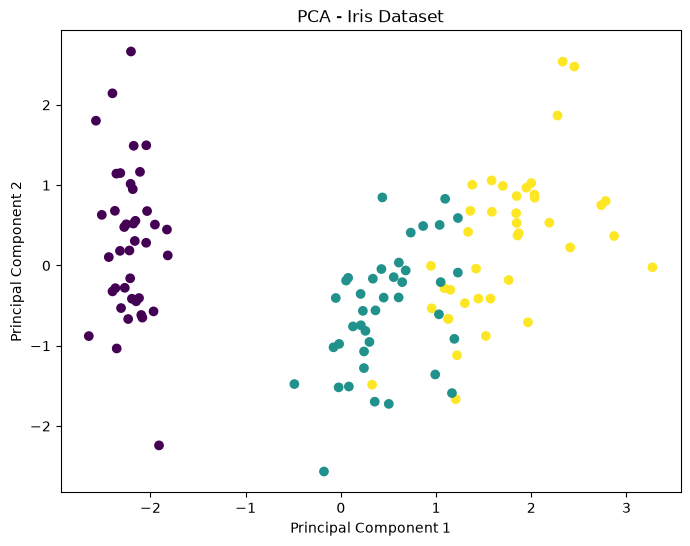

In [14]:
# 12. Visualization
plt.figure(figsize=(8, 6))

plt.scatter(
    X_train_pca[:, 0],
    X_train_pca[:, 1],
    c=y_train
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA - Iris Dataset")

plt.show()